# From audio to spectrogram

The model does not learn from raw audio. It learns from mel-spectrograms, which are images of sound with time on one axis and frequency on the other, and loudness shown as brightness. Converting audio to an image is what allows a convolutional network, designed for pictures, to be used on sound.

This notebook builds the first spectrogram and compares the two kinds of audio in the dataset. That contrast is the central difficulty of the project.

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

## A field soundscape

This is one minute from site S22, recorded at 20:15. It is passive field audio: a recorder left in the wetland, capturing whatever happened to be calling.

c:\Users\guech\OneDrive\Desktop\Msc Data Science\Individual Project\mapping-biodiversity-from-sound\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sample rate: 32000
duration (seconds): 60.0
spectrogram shape: (128, 3751)


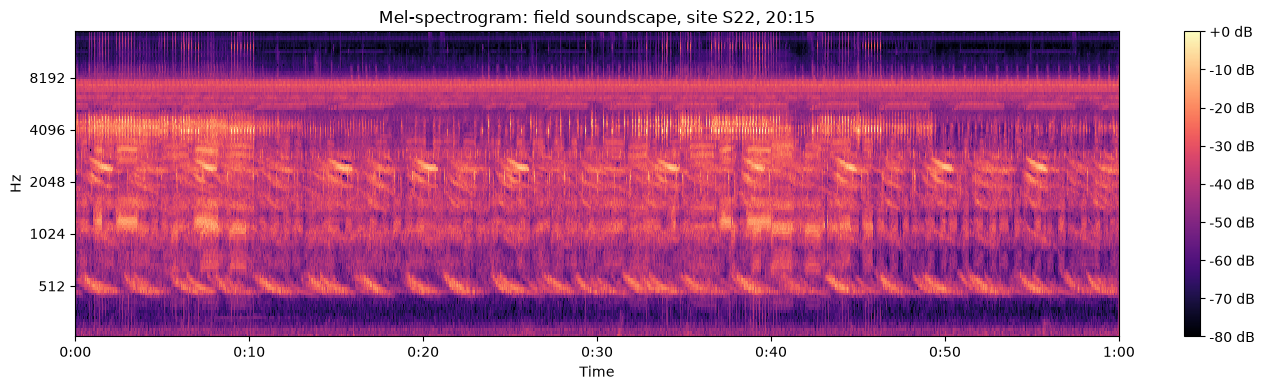

In [2]:
path_ss = '../data/BC2026_Train_0039_S22_20211231_201500.ogg'

y, sr = librosa.load(path_ss, sr=32000)
print("sample rate:", sr)
print("duration (seconds):", round(len(y) / sr, 1))

mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmin=40, fmax=15000)
mel_db = librosa.power_to_db(mel, ref=np.max)
print("spectrogram shape:", mel_db.shape)

plt.figure(figsize=(14, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', fmin=40, fmax=15000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-spectrogram: field soundscape, site S22, 20:15')
plt.tight_layout()
plt.show()

The recording is dense and almost continuous. The repeating vertical bursts between roughly 1000 and 4000 Hz are an insect chorus, which is what dominates a wetland at night. There is very little silence anywhere in the minute.

Loading at a fixed sample rate of 32 kHz standardises every file, since the model needs consistently shaped input. The frequency range is bounded between 40 Hz and 15 kHz to cut sub-audible rumble at the bottom and mostly-noise at the top.

## A focal clip

The training audio is a different kind of recording entirely. Focal clips come from Xeno-canto and iNaturalist, where a person deliberately pointed a microphone at one animal and recorded it calling.

duration (seconds): 28.4


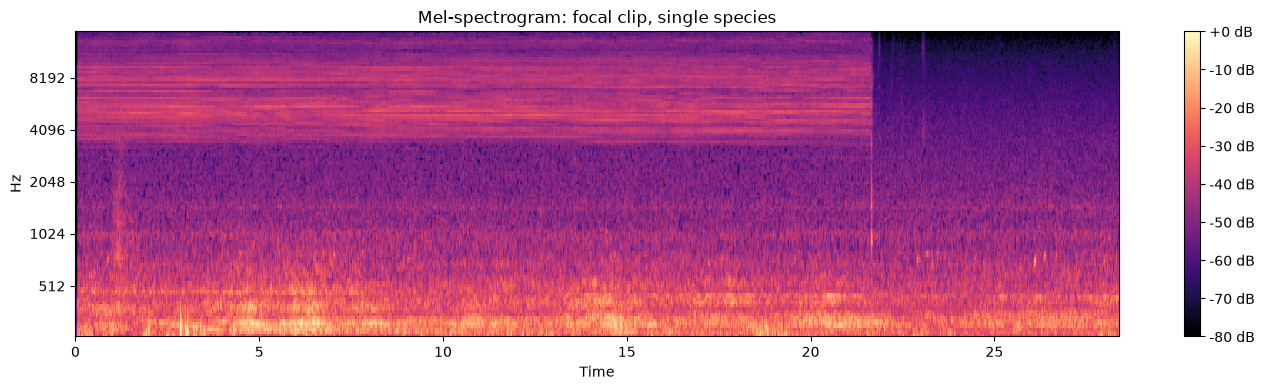

: 

In [ ]:
path_focal = '../data/iNat1114648.ogg'

y_f, sr_f = librosa.load(path_focal, sr=32000)
print("duration (seconds):", round(len(y_f) / sr_f, 1))

mel_f = librosa.feature.melspectrogram(y=y_f, sr=sr_f, n_mels=128, fmin=40, fmax=15000)
mel_f_db = librosa.power_to_db(mel_f, ref=np.max)

plt.figure(figsize=(14, 4))
librosa.display.specshow(mel_f_db, sr=sr_f, x_axis='time', y_axis='mel', fmin=40, fmax=15000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-spectrogram: focal clip, single species')
plt.tight_layout()
plt.show()

## Why this comparison matters

The model is trained overwhelmingly on focal clips, since that is where the labelled data is. It is then asked to work on field soundscapes, which is what passive acoustic monitoring actually produces.

The two images above show why this is hard. A focal clip presents a call against a quieter background, while a soundscape presents the same call, if it is there at all, buried inside an insect chorus, overlapping with other species, and at whatever distance the animal happened to be from the recorder. In practice focal clips vary too, and many carry background noise of their own, so the divide is a tendency rather than a clean rule.

This is the domain shift the project has to confront, and the gap between performance on clean audio and performance on field audio is one of the main things this project measures.